<a href="https://colab.research.google.com/github/Sherry66410/ML-PROJECT/blob/main/Sherry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [27]:
df=pd.read_csv("/content/the_loan.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [29]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [30]:
columns=['Loan_ID','Gender']
for col in columns:
  df.drop(col,axis=1,inplace=True)


In [31]:
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...
609,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [32]:
df.isnull().sum()

,0
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Property_Area,0


In [33]:
columns=['Married','Dependents','Self_Employed']
df=df.dropna(subset=columns)

In [34]:
df.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,19
Loan_Amount_Term,12
Credit_History,44
Property_Area,0


In [35]:

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

/tmp/ipykernel_525/947946403.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_525/947946403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)


In [36]:

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

/tmp/ipykernel_525/58533270.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
/tmp/ipykernel_525/58533270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)


In [37]:

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_525/4277922648.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
/tmp/ipykernel_525/4277922648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


In [38]:
df.isnull().sum()

,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area,0


In [39]:
df_corr=df.corr(numeric_only=True)

<Axes: >

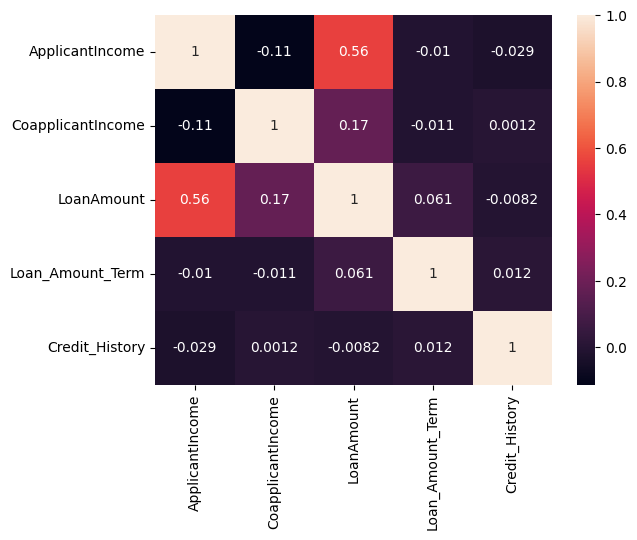

In [40]:
sns.heatmap(df_corr,annot=True)

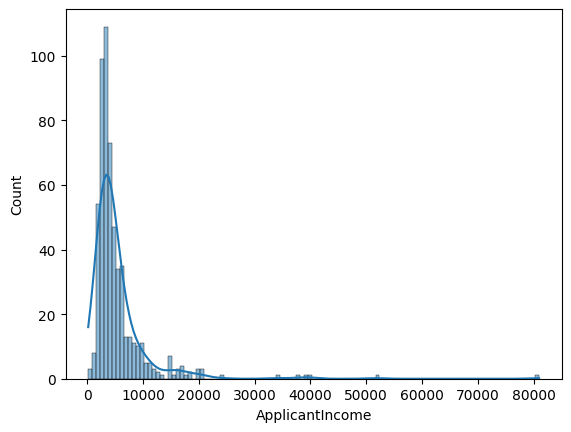

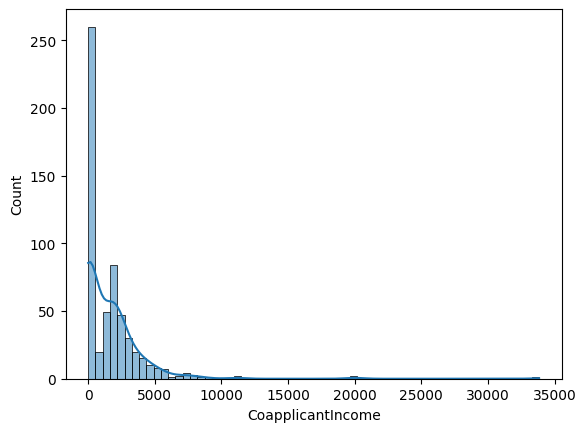

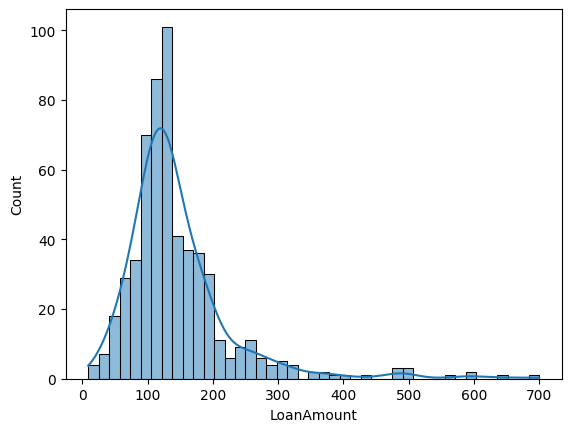

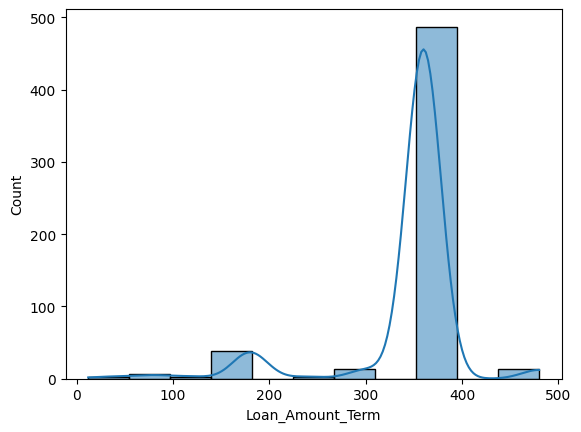

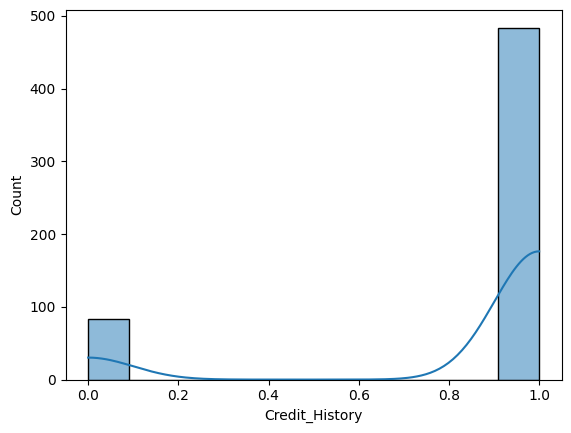

In [41]:
columns=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
for col in columns:
  sns.histplot(df[col],kde=True)
  plt.show()

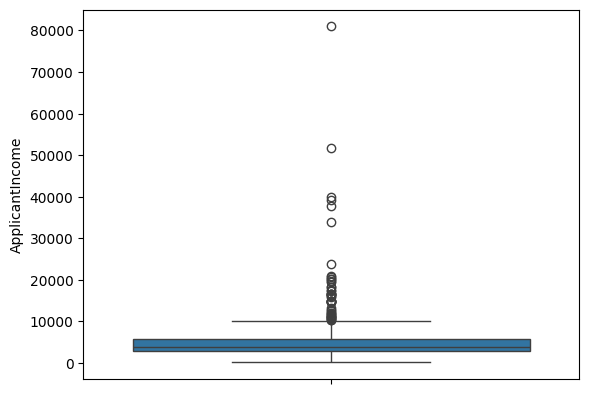

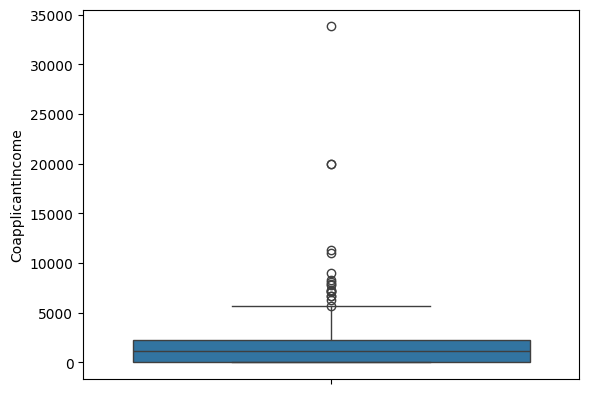

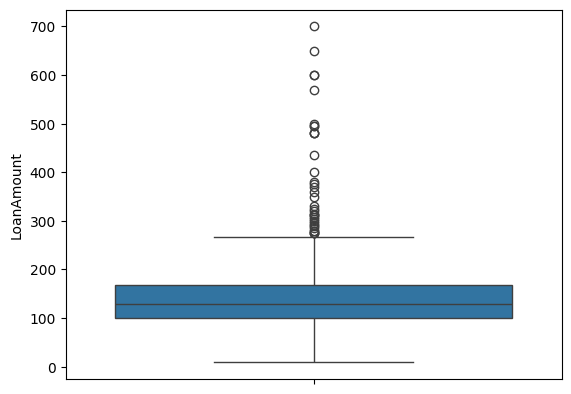

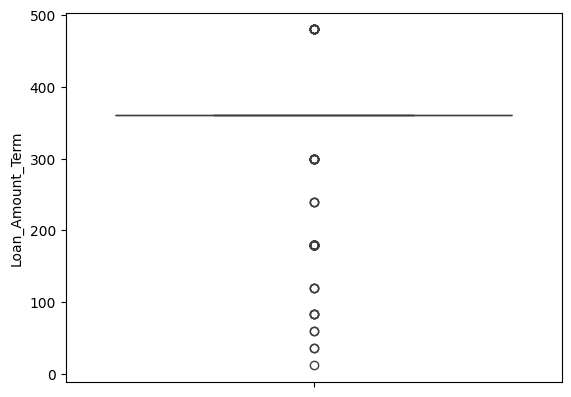

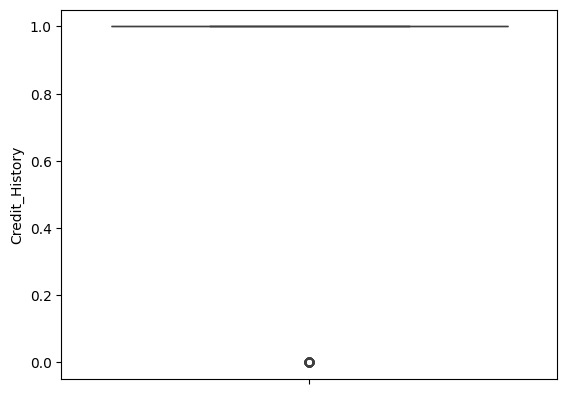

In [42]:
columns=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
for col in columns:
  sns.boxplot(df[col]) # Removed kde=True
  plt.show()

In [46]:
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['CoapplicantIncome_log'] = np.log1p(df['CoapplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

/tmp/ipykernel_525/392116769.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
/tmp/ipykernel_525/392116769.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CoapplicantIncome_log'] = np.log1p(df['CoapplicantIncome'])
/tmp/ipykernel_525/392116769.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

<Axes: ylabel='ApplicantIncome_log'>

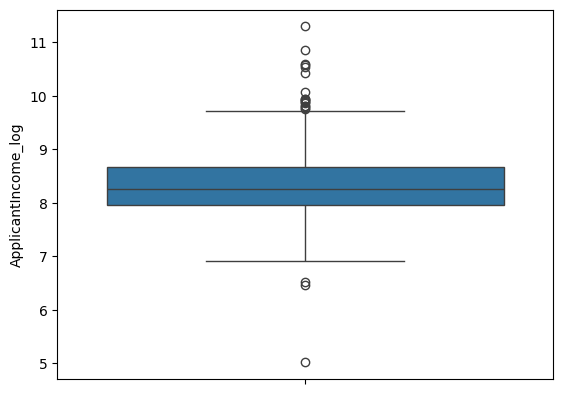

In [47]:
sns.boxplot(df['ApplicantIncome_log'])

In [49]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Loan_Status']=le.fit_transform(df['Loan_Status'])

/tmp/ipykernel_525/2731438389.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Loan_Status']=le.fit_transform(df['Loan_Status'])


In [50]:
df

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log
0,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,8.674197,0.000000,4.859812
1,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,8.430327,7.319202,4.859812
2,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,8.006701,0.000000,4.204693
3,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,7.857094,7.765993,4.795791
4,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,8.699681,0.000000,4.955827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1,7.972811,0.000000,4.276666
610,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1,8.320448,0.000000,3.713572
611,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1,8.996280,5.484797,5.537334
612,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1,8.933796,0.000000,5.236442


In [51]:
df.corr(numeric_only=True)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log
ApplicantIncome,1.000000,-0.113498,0.559183,-0.010211,-0.028778,-0.018224,0.808656,-0.246463,0.437252
CoapplicantIncome,-0.113498,1.000000,0.174382,-0.011064,0.001198,-0.037306,-0.183280,0.641060,0.203805
LoanAmount,0.559183,0.174382,1.000000,0.061342,-0.008155,-0.031362,0.571589,0.057470,0.896128
Loan_Amount_Term,-0.010211,-0.011064,0.061342,1.000000,0.011869,-0.013233,-0.029697,0.005903,0.098002
Credit_History,-0.028778,0.001198,-0.008155,0.011869,1.000000,0.539328,0.016939,0.005243,-0.025300
Loan_Status,-0.018224,-0.037306,-0.031362,-0.013233,0.539328,1.000000,0.008793,0.058324,-0.035016
ApplicantIncome_log,0.808656,-0.183280,0.571589,-0.029697,0.016939,0.008793,1.000000,-0.353912,0.513739
CoapplicantIncome_log,-0.246463,0.641060,0.057470,0.005903,0.005243,0.058324,-0.353912,1.000000,0.140889
LoanAmount_log,0.437252,0.203805,0.896128,0.098002,-0.025300,-0.035016,0.513739,0.140889,1.000000


<Axes: >

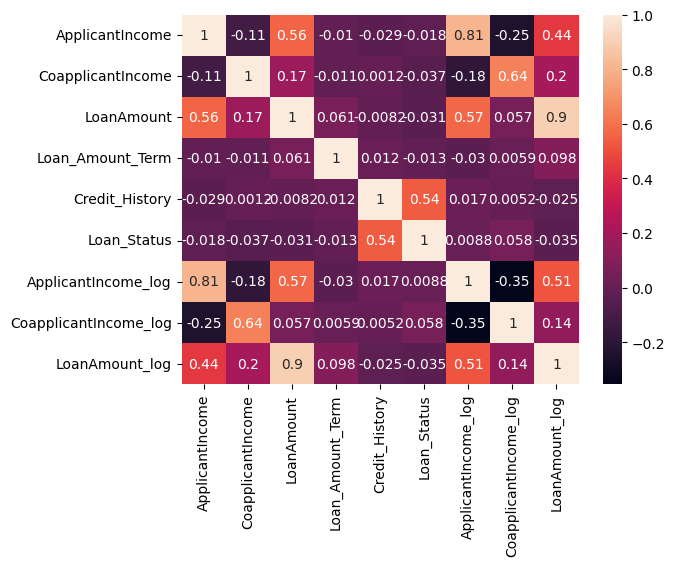

In [52]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [53]:
df.nunique()

,0
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,474
CoapplicantIncome,274
LoanAmount,198
Loan_Amount_Term,10
Credit_History,2
Property_Area,3


In [55]:
columns=['Education','Self_Employed','Loan_Status','Married']
for col in columns:
  df[col]=le.fit_transform(df[col])

/tmp/ipykernel_525/3362606282.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipykernel_525/3362606282.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col]=le.fit_transform(df[col])
/tmp/ipykernel_525/3362606282.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [57]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

In [60]:
pd.get_dummies(data=df,columns=['Dependents','Property_Area'])

,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,ApplicantIncome_log,CoapplicantIncome_log,LoanAmount_log,Dependents_0,Dependents_1,Dependents_2,Dependents_3,Property_Area_0,Property_Area_1,Property_Area_2
0,0,0,0,5849,0.0,128.0,360.0,1.0,1,8.674197,0.000000,4.859812,True,False,False,False,False,False,True
1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,8.430327,7.319202,4.859812,False,True,False,False,True,False,False
2,1,0,1,3000,0.0,66.0,360.0,1.0,1,8.006701,0.000000,4.204693,True,False,False,False,False,False,True
3,1,1,0,2583,2358.0,120.0,360.0,1.0,1,7.857094,7.765993,4.795791,True,False,False,False,False,False,True
4,0,0,0,6000,0.0,141.0,360.0,1.0,1,8.699681,0.000000,4.955827,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,2900,0.0,71.0,360.0,1.0,1,7.972811,0.000000,4.276666,True,False,False,False,True,False,False
610,1,0,0,4106,0.0,40.0,180.0,1.0,1,8.320448,0.000000,3.713572,False,False,False,True,True,False,False
611,1,0,0,8072,240.0,253.0,360.0,1.0,1,8.996280,5.484797,5.537334,False,True,False,False,False,False,True
612,1,0,0,7583,0.0,187.0,360.0,1.0,1,8.933796,0.000000,5.236442,False,False,True,False,False,False,True


In [62]:
df.dtypes

,0
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64
Property_Area,int64
